In [1]:
#Imports + Reproducibility
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import os

np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
import tensorflow as tf  # ensure tf is defined in this cell
model = tf.keras.models.load_model("pneumonia_3class_97_perfection.h5", compile=False)

In [ ]:
#Loading of dataset

from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_dir = "Universal_Dataset"

datagen = ImageDataGenerator(rescale=1./255)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 11712 images belonging to 3 classes.


In [ ]:
#prediction generation
pred_probs = model.predict(test_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes

366/366 ━━━━━━━━━━━━━━━━━━━━ 962s 3s/step


In [ ]:
#accuracy metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")

Accuracy: 81.28%
Precision: 0.829
Recall: 0.813
F1 Score: 0.812


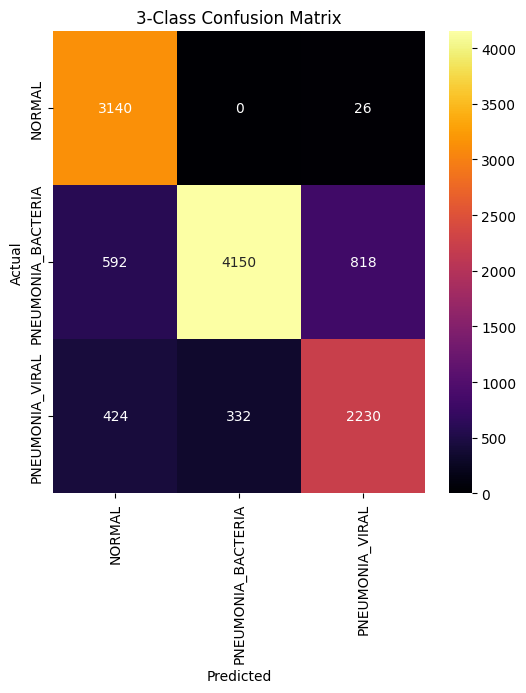

In [ ]:
#confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys(),
            cmap='inferno')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("3-Class Confusion Matrix")
plt.show()

In [ ]:
#classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=test_generator.class_indices.keys()
)

print(report)

                    precision    recall  f1-score   support

            NORMAL       0.76      0.99      0.86      3166
PNEUMONIA_BACTERIA       0.93      0.75      0.83      5560
   PNEUMONIA_VIRAL       0.73      0.75      0.74      2986

          accuracy                           0.81     11712
         macro avg       0.80      0.83      0.81     11712
      weighted avg       0.83      0.81      0.81     11712



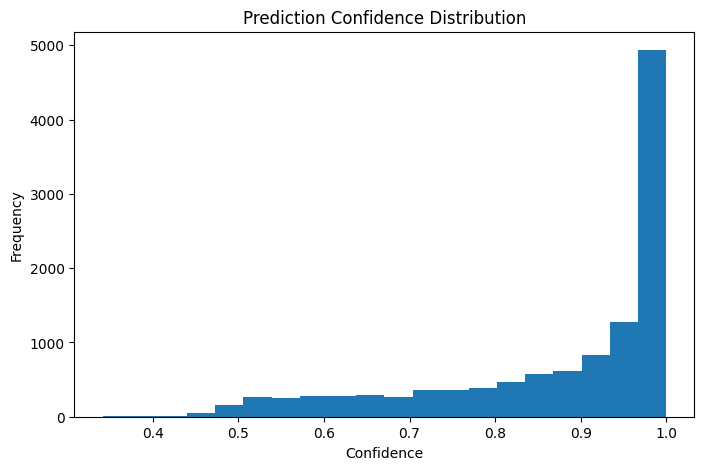

In [ ]:
#confidence distribution
max_confidence = np.max(pred_probs, axis=1)

plt.figure(figsize=(8,5))
plt.hist(max_confidence, bins=20)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#external_validation
external_confidences = []

# append confidence manually during tests

print("Average External Confidence:",
      np.mean(external_confidences))

Average External Confidence: nan


c:\Users\mpus3\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\mpus3\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
